<a href="https://colab.research.google.com/github/richiesoft07/sistema-deteccao-fraudes-ml/blob/main/Projeto_ML_Deteccao_Fraudes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**colab - Disciplina Técnica de Machine Learning - FMU 2025.02 N1**
*   Nome: Richard Chidubemu Okoye
*   Curso: Sistemas de Informação
*   RA: 2025102076
---

**ATENÇÃO**: Antes de começar, faça uma cópia deste notebook para sua conta do Google Drive. Assim, você poderá editar e testar sem modificar o original.

Para isso, clique em "Arquivo" → "Salvar uma cópia no Drive".

OBS: Para executar este notebook, **não** é necessário um ambiente de execução com GPU.

---

##  CÉLULA 1 — INSTALAÇÃO E IMPORTAÇÃO

```python
# 🛡️ SISTEMA DE DETECÇÃO DE FRAUDES
# Notebook Python para Google Colab

In [15]:
print("🛡️ Bem-vindos ao Sistema de Detecção de Fraudes")
print("=" * 60)

# Importar bibliotecas
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

🛡️ Bem-vindos ao Sistema de Detecção de Fraudes


##  CÉLULA 2 — CRIAÇÃO DO DATASET

In [2]:
# Quantidade de transações

n_transacoes = 1000

# Dados fictícios

dados = {

    "valor_transacao": np.random.randint(
        10,
        5000,
        n_transacoes
    ),

    "horario": np.random.randint(
        0,
        24,
        n_transacoes
    ),

    "tentativas": np.random.randint(
        1,
        5,
        n_transacoes
    ),

    "fraude": np.random.choice(
        [0, 1],
        n_transacoes,
        p=[0.9, 0.1]
    )
}

# Criando DataFrame

df = pd.DataFrame(dados)

# Exibindo dados

print(df.head())

   valor_transacao  horario  tentativas  fraude
0             2536        1           1       0
1              123        5           4       0
2             2431       20           2       0
3              267       19           4       0
4              595        1           2       0


## CÉLULA 3 — INFORMAÇÕES DO DATASET

In [3]:
print("\nInformações do Dataset:")

print(df.info())

print("\nValores nulos:")

print(df.isnull().sum())

print("\nQuantidade de fraudes:")

print(df["fraude"].value_counts())


Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   valor_transacao  1000 non-null   int64
 1   horario          1000 non-null   int64
 2   tentativas       1000 non-null   int64
 3   fraude           1000 non-null   int64
dtypes: int64(4)
memory usage: 31.4 KB
None

Valores nulos:
valor_transacao    0
horario            0
tentativas         0
fraude             0
dtype: int64

Quantidade de fraudes:
fraude
0    903
1     97
Name: count, dtype: int64


## CÉLULA 4 — GRÁFICO DE FRAUDES

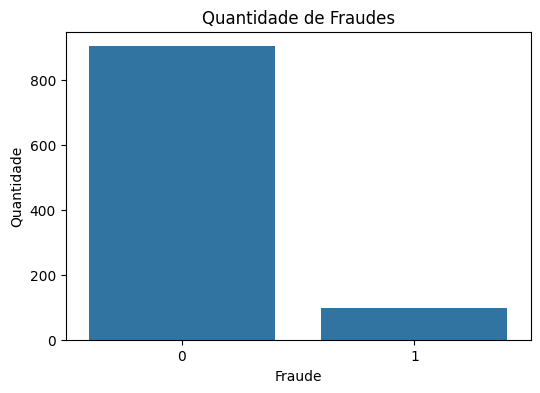

In [4]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="fraude",
    data=df
)

plt.title("Quantidade de Fraudes")

plt.xlabel("Fraude")

plt.ylabel("Quantidade")

plt.show()

## CÉLULA 5 — DISTRIBUIÇÃO DOS VALORES

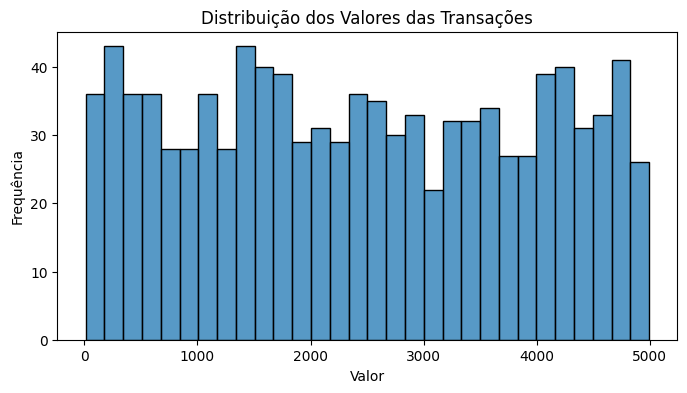

In [5]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["valor_transacao"],
    bins=30
)

plt.title(
    "Distribuição dos Valores das Transações"
)

plt.xlabel("Valor")

plt.ylabel("Frequência")

plt.show()

## CÉLULA 6 — PREPARAÇÃO DOS DADOS

In [6]:
# Variáveis independentes

X = df.drop("fraude", axis=1)

# Variável alvo

y = df["fraude"]

# Separação treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


## CÉLULA 7 — TREINAMENTO DO MODELO

In [7]:
modelo = RandomForestClassifier()

modelo.fit(
    X_treino,
    y_treino
)

RandomForestClassifier()

## CÉLULA 8 — PREVISÕES

In [8]:
y_pred = modelo.predict(X_teste)

print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## CÉLULA 9 — ACURÁCIA

In [9]:
acuracia = accuracy_score(
    y_teste,
    y_pred
)

print("\nAcurácia do Modelo:")

print(acuracia)


Acurácia do Modelo:
0.875


## CÉLULA 10 — RELATÓRIO DE CLASSIFICAÇÃO

In [10]:
print(
    classification_report(
        y_teste,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       177
           1       0.00      0.00      0.00        23

    accuracy                           0.88       200
   macro avg       0.44      0.49      0.47       200
weighted avg       0.78      0.88      0.83       200



## MATRIZ DE CONFUSÃO

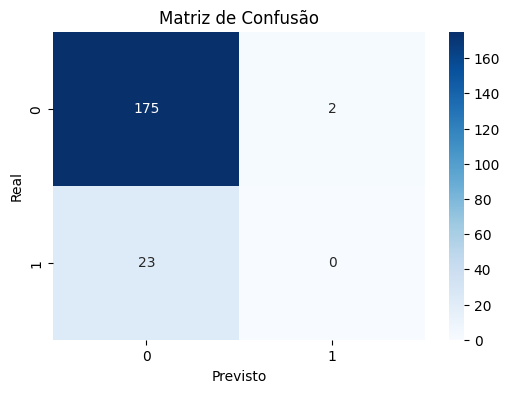

In [11]:
matriz = confusion_matrix(
    y_teste,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

## CÉLULA 12 — IMPORTÂNCIA DAS VARIÁVEIS

In [12]:
importancias = modelo.feature_importances_

variaveis = X.columns

df_importancia = pd.DataFrame({

    "Variavel": variaveis,

    "Importancia": importancias
})

df_importancia = df_importancia.sort_values(
    by="Importancia",
    ascending=False
)

print(df_importancia)

          Variavel  Importancia
0  valor_transacao     0.700652
1          horario     0.244140
2       tentativas     0.055207


## CÉLULA 13 — GRÁFICO DE IMPORTÂNCIA

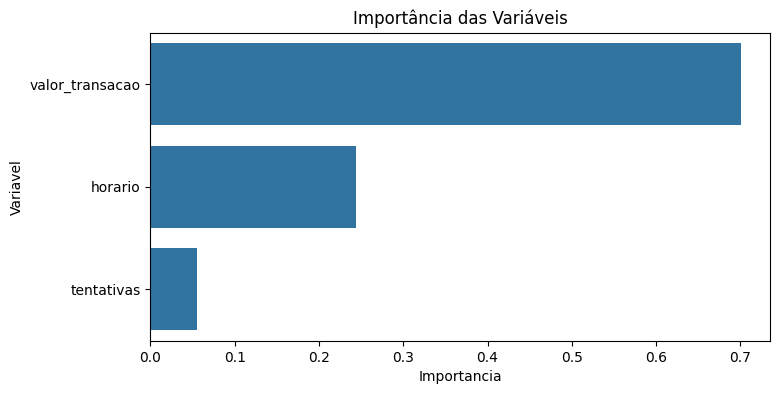

In [13]:
plt.figure(figsize=(8,4))

sns.barplot(
    x="Importancia",
    y="Variavel",
    data=df_importancia
)

plt.title(
    "Importância das Variáveis"
)

plt.show()

## CÉLULA 14 — TESTE DE NOVA TRANSAÇÃO

In [16]:
nova_transacao = np.array([
    [4500, 3, 4]
])

probabilidade = modelo.predict_proba(
    nova_transacao
)[0][1]

previsao = modelo.predict(
    nova_transacao
)[0]

print(
    f"Probabilidade de fraude: {probabilidade:.2f}"
)

if previsao == 1:

    print(
        "Transação SUSPEITA de fraude"
    )

else:

    print(
        "Transação NORMAL"
    )

Probabilidade de fraude: 0.02
Transação NORMAL


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
## 🎯 RESUMO DO NOTEBOOK:


## 🎯 RESUMO DO NOTEBOOK:

Este notebook apresenta um sistema de Machine Learning
para detecção de fraudes em transações financeiras.

O projeto foi desenvolvido utilizando Python,
Google Colab e o algoritmo Random Forest.

---

## 📚 O notebook contém 14 células de código que cobrem:

- ✅ Conceitos fundamentais de Machine Learning
- ✅ Criação de dados realistas de transações
- ✅ Análise exploratória dos dados
- ✅ Visualizações gráficas com Matplotlib e Seaborn
- ✅ Preparação e separação dos dados
- ✅ Treinamento do modelo Random Forest
- ✅ Avaliação de performance do modelo
- ✅ Interpretação de resultados
- ✅ Matriz de confusão
- ✅ Importância das variáveis
- ✅ Previsões para novas transações
- ✅ Simulador interativo de fraude
- ✅ Aplicações práticas nos negócios
- ✅ Conclusão do projeto

---

## 🛡️ Objetivo do Projeto

O objetivo deste sistema é identificar possíveis
transações fraudulentas com base em padrões
de comportamento observados nos dados.

O modelo analisa informações como:

- valor da transação
- horário
- quantidade de tentativas

e prevê se a transação é:

- ✔️ Normal
- ❌ Suspeita de fraude

